<a href="https://colab.research.google.com/github/mohammed-raihan/udl-book/blob/main/CIFAR_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import random
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [3]:
transforms = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 4

train_set = torchvision.datasets.CIFAR10(root='./data', train=True,download=True, transform=transforms)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size,shuffle=True, num_workers=2)

test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)


classes = ('plane', 'car', 'bird', 'cat','deer', 'dog', 'frog', 'horse', 'ship', 'truck')



100%|██████████| 170M/170M [00:02<00:00, 75.4MB/s]


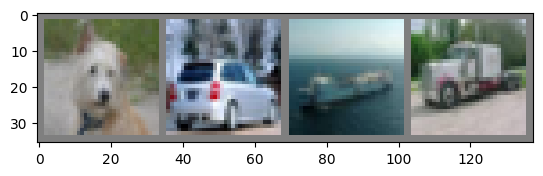

dog   car   ship  truck


In [6]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):

  img = img/2 + 0.5
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1, 2, 0)))
  plt.show()


# random traning images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# show image
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))


In [55]:
# define a CNN

class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 6, 5)
    self.bn1 = nn.BatchNorm2d(6)
    self.conv2 = nn.Conv2d(6, 16, 5)
    self.bn2 = nn.BatchNorm2d(16)
    self.pool = nn.MaxPool2d(2, 2)

    self.fc1 = nn.Linear(16 * 5 * 5, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward (self, x):

    x = self.conv1(x)
    x = self.bn1(x)
    x = F.relu(x)
    x = self.pool(x)

    x = self.conv2(x)
    x = self.bn2(x)
    x = F.relu(x)
    x = self.pool(x)

    x = torch.flatten(x,1) # flatten all dimention

    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)

    return x


net = Net()

In [57]:
# He initialization of weights
def weights_init(layer_in):
  if isinstance(layer_in, nn.Linear):
    nn.init.kaiming_uniform_(layer_in.weight)
    layer_in.bias.data.fill_(0.0)

net.apply(weights_init);

In [59]:
# define a loss function and optimizer

import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)

In [60]:
# train the network

for epoch in range(4): # loop over the dataset ten times
  running_loss = 0
  for i, data in enumerate(train_loader, 0):
    # get the inputs; data is a list of [inputs, labels]
    inputs, labels = data

    # zero the param gradient
    optimizer.zero_grad()

    # forward + backward + optimize
    output = net(inputs)
    loss = criterion(output, labels)
    loss.backward()
    optimizer.step()

    # print stats
    running_loss += loss.item()
    if i % 2000 == 1999: #print every 2000 mini batches
      print(f'[{epoch+1}, {i+1: 5d}] loss: {running_loss/2000: 3f}')
      running_loss = 0.0

print('Finished Training')

[1,  2000] loss:  1.922194
[1,  4000] loss:  1.709707
[1,  6000] loss:  1.593632
[1,  8000] loss:  1.543435
[1,  10000] loss:  1.494684
[1,  12000] loss:  1.456206
[2,  2000] loss:  1.391893
[2,  4000] loss:  1.350704
[2,  6000] loss:  1.336757
[2,  8000] loss:  1.346628
[2,  10000] loss:  1.332271
[2,  12000] loss:  1.302051
[3,  2000] loss:  1.216296
[3,  4000] loss:  1.261352
[3,  6000] loss:  1.226539
[3,  8000] loss:  1.231987
[3,  10000] loss:  1.237061
[3,  12000] loss:  1.226809
[4,  2000] loss:  1.161728
[4,  4000] loss:  1.183241
[4,  6000] loss:  1.189834
[4,  8000] loss:  1.170940
[4,  10000] loss:  1.174633
[4,  12000] loss:  1.151611
Finished Training


In [66]:
PATH = './cifar_net.pth'
torch.save(net.state_dict(), PATH)

In [32]:
net = Net()
net.load_state_dict(torch.load(PATH, weights_only=True))

<All keys matched successfully>

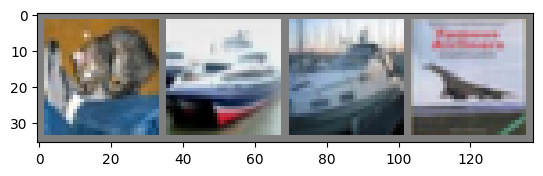

GroundTruth:  cat   ship  ship  plane


In [61]:
dataiter = iter(test_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [62]:
outputs = net(images)

_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(4)))

Predicted:  cat   car   truck plane


In [63]:
correct = 0
total = 0

with torch.no_grad():
  for data in test_loader:
    images, labels = data # Correctly assign current batch labels to 'labels'
    outputs = net(images)

    _, predicted = torch.max(outputs, 1)
    total += labels.size(0) # Use the correct 'labels' from the current batch
    correct += (predicted == labels).sum().item() # Use the correct 'labels' from the current batch

print(f'Accuracy of the network on the 10000 images: {100*correct//total}%')

Accuracy of the network on the 10000 images: 56%


In [64]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in test_loader:
        images, labels = data
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 55.8 %
Accuracy for class: car   is 84.0 %
Accuracy for class: bird  is 54.8 %
Accuracy for class: cat   is 40.3 %
Accuracy for class: deer  is 44.4 %
Accuracy for class: dog   is 48.6 %
Accuracy for class: frog  is 55.6 %
Accuracy for class: horse is 63.1 %
Accuracy for class: ship  is 71.6 %
Accuracy for class: truck is 49.9 %


In [46]:
from collections import Counter

# Initialize counter
class_counts = Counter()

# Iterate through the loader to count labels
for _, labels in train_loader:
    class_counts.update(labels.tolist())

# Map indices back to class names and print
for i, count in class_counts.items():
    print(f"Class {classes[i]}: {count}")

Class horse: 5000 images
Class bird: 5000 images
Class truck: 5000 images
Class dog: 5000 images
Class car: 5000 images
Class cat: 5000 images
Class deer: 5000 images
Class frog: 5000 images
Class ship: 5000 images
Class plane: 5000 images
